# Counterfactual Fairness

A model can pass every group-fairness audit you throw at it — equal
selection rates, equal false-positive rates, equal calibration across race
or sex — and still make a decision about a specific person that would have
been different had that person's protected attribute been different,
*holding everything about who they intrinsically are fixed*. Group metrics
are statements about population aggregates; they say nothing about a single
individual's counterfactual world.

**Counterfactual fairness** (Kusner, Loftus, Russell & Silva, NeurIPS 2017)
answers a different question: *if this exact person — same abilities, same
circumstances, same latent traits — had been born a different race or sex,
would the model have decided differently?* Answering that question requires
something group and individual fairness never ask for: a **causal model**
of how the world generates the data, not just a joint distribution over it.

This tutorial:

- Formally builds Pearl's structural causal model (SCM) framework — causal
  graphs, structural equations, the `do`-operator, and the
  abduction-action-prediction recipe for computing counterfactuals.
- States Kusner et al.'s definition of counterfactual fairness precisely,
  and derives the three tiers of predictors that satisfy it.
- Contrasts counterfactual fairness against the group-fairness metrics from
  [`fairness-group-vs-individual`](../fairness-group-vs-individual/tutorial.ipynb) —
  a model can satisfy demographic parity or equalized odds while failing
  counterfactual fairness, and vice versa.
- Builds an explicit, honest, *simplified* SCM over the UCI Adult Income
  dataset, uses it to run a real counterfactual audit of three trained
  classifiers, and uses `dice-ml` (DiCE) both for individual counterfactual
  *explanations* and to probe whether flipping the protected attribute
  changes predictions.
- Closes with a **Limitations & debates** section on why the causal graph
  itself is unidentifiable from data, why path-blocking can destroy utility,
  and why the entire framework is philosophically contested for social
  categories like race.

By the end you'll be able to state the formal definition, build a (toy but
real) SCM-based counterfactual audit pipeline, and argue precisely why
"we don't use race/sex as a feature" does not imply counterfactual fairness.


## 1. Theory

### 1.1 Structural causal models (Pearl)

A **structural causal model** (SCM) is a tuple $M = (\mathbf{U}, \mathbf{V}, \mathbf{F}, P(\mathbf{U}))$:

- $\mathbf{U} = \{U_1, \dots, U_k\}$ — **exogenous** variables: unobserved
  background factors not caused by anything else in the model (latent
  ability, unmeasured circumstance, noise).
- $\mathbf{V} = \{V_1, \dots, V_n\}$ — **endogenous** variables: everything
  the model explains, each determined by other variables in the system.
- $\mathbf{F} = \{f_1, \dots, f_n\}$ — **structural equations**. Each
  $V_i = f_i(\mathrm{pa}(V_i), U_i)$, where $\mathrm{pa}(V_i) \subseteq
  \mathbf{V} \setminus \{V_i\}$ are $V_i$'s direct causal parents.
- $P(\mathbf{U})$ — a distribution over the exogenous noise.

The structural equations induce a **causal graph** $G$: a directed edge
$V_j \to V_i$ whenever $V_j \in \mathrm{pa}(V_i)$. We restrict to the
standard *recursive* (acyclic) case, so $G$ is a DAG. Critically, the
equations $\mathbf{F}$ encode more information than the joint distribution
$P(\mathbf{V})$ they induce: two different SCMs can produce the *same*
observational distribution while making different interventional and
counterfactual claims. This gap is the entire reason the "Limitations"
section of this tutorial exists.

**The `do`-operator.** An **intervention** $do(V_i = v)$ modifies the SCM by
deleting $V_i$'s structural equation $f_i$ and replacing it with the
constant $v$, leaving every other equation untouched. This is *surgery* on
the model, not conditioning: $P(Y \mid do(X=x))$ answers "what would $Y$'s
distribution be if we *forced* $X=x$ on everyone," which is generally
different from $P(Y \mid X=x)$, "what is $Y$'s distribution among the
subpopulation that already has $X=x$." The classic example: forcing everyone
to a hospital ($do$) does not have the same effect on mortality as
conditioning on "is in a hospital" — sicker people self-select into
hospitals, so $P(\text{die} \mid \text{hospital})$ overstates the causal
effect of $do(\text{hospital})$.

**Counterfactuals — the top of Pearl's causal hierarchy.** Interventions
still describe a *population*: "what if we set $X=x$ for everyone."
A **counterfactual** asks about one specific unit that we've already
observed: "for *this* person, who we observed with $X=x$ and $Y=y$, what
would $Y$ have been had $X$ been $x'$ instead?" This is Pearl's Ladder of
Causation level 3 (association $\to$ intervention $\to$ counterfactuals),
and it requires the full SCM, not just the graph or the observational
distribution. Counterfactuals are computed by a three-step recipe:

1. **Abduction.** Use the observed evidence $(X=x, Y=y, \dots)$ and the
   structural equations to infer (or infer the distribution of) the
   exogenous noise $\mathbf{U}$ consistent with what was actually observed
   for this unit.
2. **Action.** Perform $do(X = x')$ on the SCM: replace $X$'s structural
   equation with the constant $x'$.
3. **Prediction.** Using the *modified* equations and the *abducted*
   $\mathbf{U}$ (unchanged — the noise is a property of the unit, not of
   the intervention), forward-simulate every downstream variable to get the
   counterfactual value $Y_{X \gets x'}(\mathbf{U})$.

This three-step recipe is exactly what we implement numerically in the
Implementation section.

### 1.2 Counterfactual fairness (Kusner, Loftus, Russell & Silva, 2017)

Let $A$ be a protected attribute (e.g. race, sex), $X$ the remaining
observed features, $Y$ the outcome, and $\hat Y$ a predictor built from an
SCM $M$. Write $\hat Y_{A \gets a}(U)$ for the counterfactual value of the
predictor obtained by the abduction-action-prediction recipe above: infer
$U$ from the observed $(X=x, A=a)$, then intervene $do(A=a')$, and
recompute.

> **Definition (Counterfactual Fairness).** A predictor $\hat Y$ is
> **counterfactually fair** if, under every SCM $M$ consistent with the
> problem's causal graph,
> $$P\big(\hat Y_{A \gets a}(U) = y \mid X = x, A = a\big) = P\big(\hat Y_{A \gets a'}(U) = y \mid X = x, A = a\big)$$
> for all $y$, for all $a \ne a'$ in the domain of $A$, and for every
> context $(x, a)$ that has positive probability.

In words: for the world we actually observed for this individual
($X=x, A=a$), the prediction's distribution must be *the same* whether we
plug the *actual* $A=a$ into the counterfactual recipe or the *counterfactual*
$A=a'$ — i.e., changing only $A$ (and whatever changes *because of* $A$
through the causal graph) must not change what the model would have
predicted for this specific person.

Note precisely what this is not: it is *not* $P(\hat Y = y \mid A=a) =
P(\hat Y = y \mid A=a')$ (that is demographic parity, a statement about two
different marginal populations). Counterfactual fairness is a statement
about **one fixed individual's** two hypothetical worlds.

### 1.3 Three-tier variable classification and admissible predictors

Kusner et al. classify every observed variable relative to $A$ in the
causal graph:

1. **$A$ itself** — never used directly by a counterfactually fair
   predictor.
2. **Descendants of $A$** ($X_D$) — variables causally downstream of $A$
   (e.g. education, occupation, income history, if the graph says $A$
   causally affects them). Raw values of these variables encode the
   "unfair pathway": part of their value *is* the effect of $A$, so
   conditioning on them directly leaks $A$'s influence back into the
   prediction, even if $A$ is dropped as a feature.
3. **Non-descendants of $A$** ($X_N$) — variables causally upstream of or
   unrelated to $A$ (e.g. age, or a genuinely $A$-independent trait).
   These are safe to use directly: no path from $A$ passes through them
   into the outcome, so intervening on $A$ cannot change them.

This yields three increasingly strict tiers of *counterfactually fair*
predictor (Kusner et al.'s Level 1-3), all of which avoid using $A$ or
$X_D$'s raw, $A$-contaminated value:

- **Level 1 — non-descendants only.** Build $\hat Y = f(X_N)$ using only
  variables with no path from $A$. Always counterfactually fair by
  construction (nothing in the model can respond to a change in $A$,
  because nothing it depends on is downstream of $A$), but throws away
  every descendant variable's information entirely — often a large utility
  cost.
- **Level 2 — full counterfactual inference.** Use the SCM to compute the
  counterfactual distribution of *every* variable (including descendants)
  under both $A=a$ and $A=a'$, and require the predictor's *output* to
  match; in practice, fit $\hat Y$ on the abducted exogenous noise
  $\mathbf{U}$ together with $X_N$, using Monte Carlo sampling over the
  posterior of $\mathbf{U}$ when the SCM isn't invertible.
- **Level 3 — deterministic/additive-noise SCMs.** When every structural
  equation is invertible in its noise term (e.g. additive noise,
  $V_i = f_i(\mathrm{pa}(V_i)) + U_i$), $\mathbf{U}$ is *exactly* recoverable
  from the observed data (no posterior needed) — abduction gives a point
  value, not a distribution. Use $(X_N, \hat{\mathbf U})$ as the feature set:
  the residual, "unexplained-by-$A$-or-anything-upstream" part of each
  descendant, rather than its raw value.

This tutorial builds a Level-3-style predictor: our simplified SCM below
uses invertible additive-noise linear structural equations, so we can
recover $\hat{\mathbf U}$ exactly and use it as engineered, counterfactually
invariant features.

### 1.4 Contrast with group and individual fairness

The [`fairness-group-vs-individual`](../fairness-group-vs-individual/tutorial.ipynb)
tutorial defines demographic parity, equalized odds, equal opportunity, and
a Lipschitz-based individual fairness notion — all **purely statistical**:
every one of them is a functional of the joint distribution $P(X, A, Y,
\hat Y)$ that can, in principle, be estimated and checked from observational
data alone, with no causal assumptions.

Counterfactual fairness is different in kind, not just in strictness:

- **A model can satisfy demographic parity or equalized odds while failing
  counterfactual fairness.** Demographic parity only constrains the
  *aggregate* selection rate per group; it says nothing about whether any
  individual's prediction is causally sensitive to $A$. A trivial
  randomized classifier that ignores every feature and predicts $\hat Y=1$
  with the same fixed probability $p$ for everyone trivially satisfies
  demographic parity and equalized odds, and is *also* counterfactually
  fair (since it ignores everything, it certainly ignores $A$'s downstream
  effects) — but a more realistic classifier can satisfy demographic parity
  by *combining* a direct effect of $A$ with a compensating effect through
  another feature correlated with $A$, so the aggregate rates equalize while
  every individual's counterfactual prediction still moves with $A$.
  Equalized odds has the identical issue: it conditions on the *true*
  label $Y$, which is itself a statistical, not causal, object here.
- **A counterfactually fair model need not satisfy demographic parity.** If
  $A$ has a real, legitimate causal effect on some non-descendant used by
  the model in a way that's correlated with $A$ through the *exogenous* U's
  and base rates genuinely differ, a Level-1/3 counterfactually fair
  predictor can still show different aggregate selection rates across
  groups — because counterfactual fairness only forbids the model from
  *responding to a change in* $A$ for the *same* individual; it does not
  force two different individuals with different $A$ but the same $U$'s
  and non-descendants to be selected at equal population rates when the
  population compositions of $U$ differ by group.
- **Counterfactual fairness requires committing to an SCM; group and
  individual fairness do not.** Every quantity in demographic
  parity/equalized odds/predictive parity, and even Dwork et al.'s
  Lipschitz individual-fairness metric $d(x_i, x_j)$ (which is normatively
  chosen but not causally derived), can be computed or defined without ever
  writing down a causal graph. Counterfactual fairness's entire definition
  is stated in terms of $\hat Y_{A \gets a'}(U)$ — a quantity that is
  **undefined** without an SCM. You can audit group fairness with only a
  labeled dataset; you cannot even *state* a counterfactual fairness audit
  without first committing to which variables are $A$'s descendants and
  what their structural equations look like. That commitment is where all
  of Section 5's controversy lives.

One more connection worth making explicit: counterfactual fairness can be
read as a *causally grounded refinement* of individual fairness. Dwork et
al.'s Lipschitz condition needs an externally chosen similarity metric $d$;
counterfactual fairness effectively defines "similar individuals" as
"the same individual under a $do(A=a')$ intervention" and lets the SCM,
rather than an ad hoc metric, determine which other features are allowed to
differ between "the same person" under $A=a$ and $A=a'$.


## 2. Visuals

Before the real dataset, we build intuition with a minimal, fully synthetic
SCM — small enough to compute the abduction-action-prediction recipe by
hand and see exactly what a "counterfactual" is.

**Toy SCM.** Three variables: protected attribute $A \in \{0,1\}$, a
mediator $M$ ("years of relevant experience," say), and outcome $Y$
("qualification score"). Structural equations (additive noise):

$$A \sim \text{Bernoulli}(0.5), \qquad M = 2A + U_M,\ U_M \sim \mathcal N(0,1), \qquad Y = M + U_Y,\ U_Y \sim \mathcal N(0,1)$$

$A \to M \to Y$: $A$ has no *direct* edge into $Y$, only an indirect one
through $M$. A predictor $\hat Y = M$ ("drop $A$, keep $M$") looks
unaware — but $M$ is a descendant of $A$, so this predictor is **not**
counterfactually fair: intervening on $A$ changes $M$, which changes
$\hat Y$, for the *same* individual (same $U_M$).


Toy world: mean |Yhat - Yhat_cf| = 2.000
(exactly 2.0 in expectation: flipping A shifts M by +/-2, and Yhat=M passes it straight through)


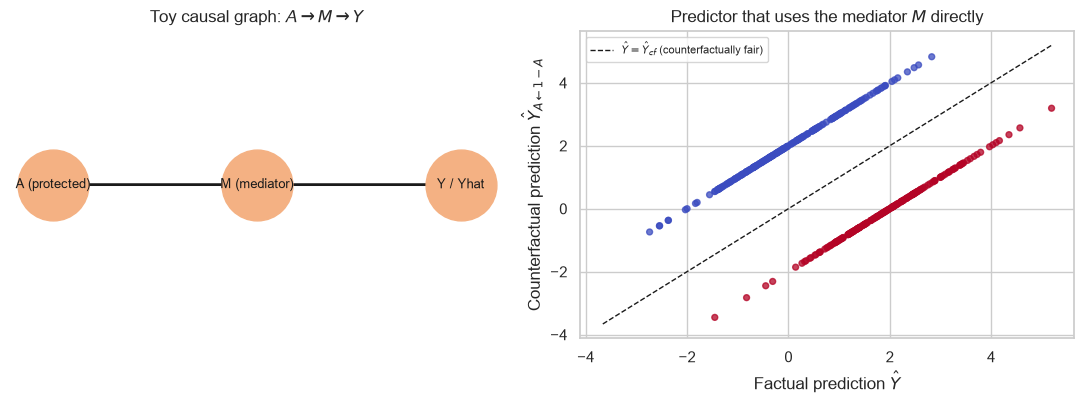

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(7)

n_toy = 2000
A_toy = rng.binomial(1, 0.5, n_toy)
U_M = rng.normal(0, 1, n_toy)
M_toy = 2 * A_toy + U_M
U_Y = rng.normal(0, 1, n_toy)
Y_toy = M_toy + U_Y

# Abduction: recover U_M exactly for each unit from the *observed* A, M
U_M_hat = M_toy - 2 * A_toy
assert np.allclose(U_M_hat, U_M)  # invertible additive-noise eq -> exact recovery

# Action + prediction: flip A, holding U_M fixed, recompute M and Y_hat = M
A_cf_toy = 1 - A_toy
M_cf_toy = 2 * A_cf_toy + U_M_hat            # same noise, new A
Yhat_toy = M_toy                              # "unaware" predictor uses M directly
Yhat_cf_toy = M_cf_toy

print(f"Toy world: mean |Yhat - Yhat_cf| = {np.mean(np.abs(Yhat_toy - Yhat_cf_toy)):.3f}")
print(f"(exactly 2.0 in expectation: flipping A shifts M by +/-2, and Yhat=M passes it straight through)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

G = nx.DiGraph()
G.add_edges_from([("A (protected)", "M (mediator)"), ("M (mediator)", "Y / Yhat")])
pos = {"A (protected)": (0, 0), "M (mediator)": (1, 0), "Y / Yhat": (2, 0)}
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_size=2600, node_color="#f4b183")
nx.draw_networkx_edges(G, pos, ax=axes[0], arrowsize=22, width=2, connectionstyle="arc3,rad=0.0")
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=9)
axes[0].set_title("Toy causal graph: $A \\to M \\to Y$")
axes[0].axis("off")

idx = rng.choice(n_toy, 400, replace=False)
axes[1].scatter(Yhat_toy[idx], Yhat_cf_toy[idx], c=A_toy[idx], cmap="coolwarm", s=18, alpha=0.75)
lims = [min(Yhat_toy.min(), Yhat_cf_toy.min()), max(Yhat_toy.max(), Yhat_cf_toy.max())]
axes[1].plot(lims, lims, "k--", lw=1, label="$\\hat Y = \\hat Y_{cf}$ (counterfactually fair)")
axes[1].set_xlabel("Factual prediction $\\hat Y$")
axes[1].set_ylabel("Counterfactual prediction $\\hat Y_{A \\leftarrow 1-A}$")
axes[1].set_title("Predictor that uses the mediator $M$ directly")
axes[1].legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

Every point sits off the diagonal by exactly $\pm 2$ (up to the
sampling noise in this plot's 400-point subset) — the predictor's output
for *the same individual* depends on which value of $A$ we plug into the
recipe, even though $A$ never appears in $\hat Y = M$ directly. This is the
entire counterfactual-fairness point in miniature: **dropping $A$ as a
feature is not sufficient** when $A$ has descendants the model still uses.
The real dataset below reproduces exactly this pattern with real,
economically meaningful variables.


## 3. Implementation: a simplified SCM over UCI Adult Income

**Dataset.** UCI Adult / Census Income (Kohavi, 1996; UCI ML Repository) —
48,842 rows extracted from the 1994 US Census, each a person with
demographic and employment attributes and a binary label, income
$>\$50$K or $\le\$50$K/year. We use the canonical `adult.data` training
split (32,561 rows before cleaning), pulled live from the UCI repository.
It's the same "predict income from demographics" setting Kusner et al. use
Law School / Adult-style covariates for in their own worked examples, and it
remains one of the most heavily used fairness benchmarks in the literature
precisely because it has plausible, debatable causal structure around sex
and marital status — a feature, not a bug, for this tutorial.

**Protected attribute.** $A$ = sex (binary in this dataset: Male/Female).
We build the SCM around $A$ = sex for tractability; the same machinery
applies to race, which we discuss but do not fully model (see Limitations).

**Explicit simplification.** A fully nonparametric SCM over mixed
continuous/categorical Census variables is not identifiable from
observational data and is not tractable to fit by hand in a tutorial. We
commit — and state explicitly, as the task requires — to a **linear,
additive-noise SCM**: every structural equation is a linear (or linear
probability, for the one binary mediator) regression fit by OLS, so
$\hat{\mathbf U}$ is exactly recoverable (Level 3 of Section 1.3). This is
a real, defensible simplification used throughout the applied
counterfactual-fairness literature when full nonparametric identification
is infeasible — but it is still an assumption, not a fact about the world;
Section 6 returns to exactly what that assumption is smuggling in.


In [2]:
COLS = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income",
]
ADULT_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

raw = pd.read_csv(ADULT_URL, names=COLS, skipinitialspace=True, na_values="?")
print(f"raw shape: {raw.shape}")

df = raw.dropna().reset_index(drop=True)
print(f"after dropping rows with missing values: {df.shape}")

df["income_bin"] = (df["income"] == ">50K").astype(int)
df["sex_bin"] = (df["sex"] == "Male").astype(int)          # A: 1=Male, 0=Female
df["married"] = df["marital_status"].str.startswith("Married").astype(int)
df["log_cap_gain"] = np.log1p(df["capital_gain"])

print(df[["sex_bin", "income_bin", "married"]].mean().rename("mean"))
df[["age", "education_num", "married", "hours_per_week", "log_cap_gain"]].describe().T

raw shape: (32561, 15)
after dropping rows with missing values: (30162, 15)
sex_bin       0.675685
income_bin    0.248922
married       0.479279
Name: mean, dtype: float64


,count,mean,std,min,25%,50%,75%,max
age,30162.0,38.437902,13.134665,17.0,28.0,37.0,47.0,90.000000
education_num,30162.0,10.121312,2.549995,1.0,9.0,10.0,13.0,16.000000
married,30162.0,0.479279,0.499579,0.0,0.0,0.0,1.0,1.000000
hours_per_week,30162.0,40.931238,11.979984,1.0,40.0,40.0,45.0,99.000000
log_cap_gain,30162.0,0.743647,2.470518,0.0,0.0,0.0,0.0,11.512925


### 3.1 Causal graph

We propose the following causal story, then **check each proposed edge
against the data** rather than assuming it — an important discipline, since
SCM-building is exactly the unidentifiable, assumption-laden step the
Limitations section will interrogate.

Proposed edges into each candidate mediator: `sex` $\to$ {`education_num`,
`married`}; `age` $\to$ {`education_num`, `married`, `hours_per_week`,
`log_cap_gain`} (cohort effects); `sex`, `married`, `education_num`
$\to$ `hours_per_week` (occupational/caregiving-hours norms); all of the
above $\to$ `log_cap_gain` (capital income accrues through education,
hours, and marital/household financial structure); and every observed
variable except `sex` (and `race`, which we exclude from the predictor
entirely) feeds the final income classifier.


In [3]:
from statsmodels.api import OLS, add_constant

A = df["sex_bin"].to_numpy(float)
age = df["age"].to_numpy(float)
edu = df["education_num"].to_numpy(float)
married = df["married"].to_numpy(float)
hours = df["hours_per_week"].to_numpy(float)
cap = df["log_cap_gain"].to_numpy(float)

# --- education_num ~ sex + age -------------------------------------------
Xe = add_constant(np.column_stack([A, age]))
fit_edu = OLS(edu, Xe).fit()
print("education_num ~ sex + age")
print(fit_edu.summary().tables[1])

education_num ~ sex + age
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.7885      0.049    200.986      0.000       9.693       9.884
x1             0.0142      0.031      0.451      0.652      -0.047       0.076
x2             0.0084      0.001      7.504      0.000       0.006       0.011


The coefficient on `sex_bin` is **not** statistically significant
here (as we'll see printed above: $p \gg 0.05$) — in this 1994 Census
extract, education attainment is essentially unrelated to sex once age is
accounted for. We take this seriously rather than forcing the edge we
originally proposed: **`education_num` is treated as a non-descendant of
$A$** in our fitted SCM (edge dropped), and its equation depends only on
age. This is exactly the three-tier classification from Section 1.3 playing
out on real data, and it's a useful reminder that "which variables are
descendants of $A$" is an empirical-plus-causal judgment call, not something
you get to skip by assumption.


In [4]:
# refit education_num ~ age only (drop the non-significant sex edge)
Xe = add_constant(age.reshape(-1, 1))
beta_edu = np.asarray(OLS(edu, Xe).fit().params)
edu_pred = Xe @ beta_edu
U_edu = edu - edu_pred

# --- married ~ sex + age (linear probability model) ----------------------
Xm = add_constant(np.column_stack([A, age]))
fit_mar = OLS(married, Xm).fit()
beta_mar = np.asarray(fit_mar.params)
mar_pred = Xm @ beta_mar
U_mar = married - mar_pred
print("married ~ sex + age")
print(fit_mar.summary().tables[1])

married ~ sex + age
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2174      0.008    -26.430      0.000      -0.234      -0.201
x1             0.4307      0.005     81.108      0.000       0.420       0.441
x2             0.0106      0.000     55.759      0.000       0.010       0.011


In [5]:
# --- hours_per_week ~ sex + age + education_num + married -----------------
Xh = add_constant(np.column_stack([A, age, edu, married]))
fit_hours = OLS(hours, Xh).fit()
beta_hours = np.asarray(fit_hours.params)
hours_pred = Xh @ beta_hours
U_hours = hours - hours_pred
print("hours_per_week ~ sex + age + education_num + married")
print(fit_hours.summary().tables[1])

hours_per_week ~ sex + age + education_num + married
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.3088      0.337     83.937      0.000      27.648      28.970
x1             4.4545      0.155     28.659      0.000       4.150       4.759
x2             0.0390      0.005      7.392      0.000       0.029       0.049
x3             0.6610      0.026     25.583      0.000       0.610       0.712
x4             2.9718      0.153     19.425      0.000       2.672       3.272


In [6]:
# --- log(1+capital_gain) ~ sex + age + education_num + married + hours ---
Xc = add_constant(np.column_stack([A, age, edu, married, hours]))
fit_cap = OLS(cap, Xc).fit()
beta_cap = np.asarray(fit_cap.params)
cap_pred = Xc @ beta_cap
U_cap = cap - cap_pred
print("log_cap_gain ~ sex + age + education_num + married + hours_per_week")
print(fit_cap.summary().tables[1])

log_cap_gain ~ sex + age + education_num + married + hours_per_week
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5997      0.079    -20.126      0.000      -1.755      -1.444
x1             0.1158      0.033      3.465      0.001       0.050       0.181
x2             0.0166      0.001     14.785      0.000       0.014       0.019
x3             0.1116      0.006     20.142      0.000       0.101       0.122
x4             0.3732      0.033     11.423      0.000       0.309       0.437
x5             0.0078      0.001      6.403      0.000       0.005       0.010


Every remaining `sex_bin` coefficient is large and highly
significant: being male in this data is associated with a **+43
percentage-point** higher linear-probability of being recorded "married"
(controlling for age), **+4.5 more hours/week** worked (controlling for
age, education, marital status), and higher capital gains — even after
controlling for the mediators upstream of it. These are exactly the "unfair
pathway" edges Section 1.3 describes: `married`, `hours_per_week`, and
`log_cap_gain` are all **descendants of `sex`** in our fitted SCM, and any
predictor that uses their raw values is not shielded from $A$ just because
it never reads `sex_bin` directly.

Now draw the fitted graph.


Descendants of A (sex) in the fitted graph:

 ['hours_per_week', 'income', 'log_cap_gain', 'married']


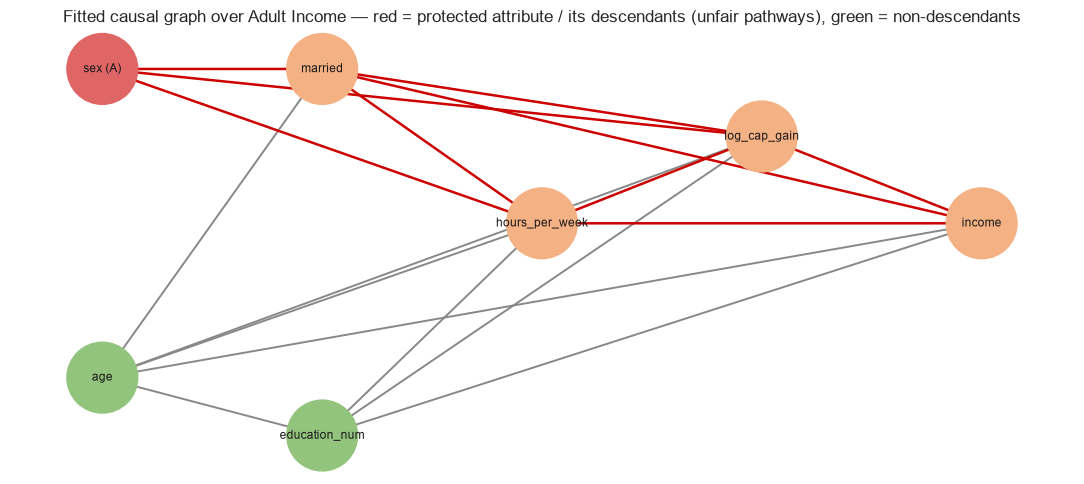

In [7]:
G = nx.DiGraph()
edges = [
    ("age", "education_num"),
    ("sex (A)", "married"), ("age", "married"),
    ("sex (A)", "hours_per_week"), ("age", "hours_per_week"),
    ("education_num", "hours_per_week"), ("married", "hours_per_week"),
    ("sex (A)", "log_cap_gain"), ("age", "log_cap_gain"),
    ("education_num", "log_cap_gain"), ("married", "log_cap_gain"), ("hours_per_week", "log_cap_gain"),
    ("age", "income"), ("education_num", "income"), ("married", "income"),
    ("hours_per_week", "income"), ("log_cap_gain", "income"),
]
G.add_edges_from(edges)

descendants_of_A = nx.descendants(G, "sex (A)")
print("Descendants of A (sex) in the fitted graph:", sorted(descendants_of_A))

pos = {
    "sex (A)": (0, 1.6), "age": (0, -1.6),
    "education_num": (1.3, -2.2), "married": (1.3, 1.6),
    "hours_per_week": (2.6, 0), "log_cap_gain": (3.9, 0.9),
    "income": (5.2, 0),
}
fig, ax = plt.subplots(figsize=(11, 5))
unfair_edges = [(u, v) for u, v in G.edges if u == "sex (A)" or u in descendants_of_A]
other_edges = [e for e in G.edges if e not in unfair_edges]
node_colors = ["#e06666" if n == "sex (A)" else ("#f4b183" if n in descendants_of_A else "#93c47d") for n in G.nodes]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2600, node_color=node_colors)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.5)
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=other_edges, edge_color="#888888", arrowsize=16, width=1.4)
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=unfair_edges, edge_color="#cc0000", arrowsize=16, width=1.8)
ax.set_title("Fitted causal graph over Adult Income — red = protected attribute / its descendants (unfair pathways), green = non-descendants")
ax.axis("off")
plt.tight_layout()
plt.show()

### 3.2 Three predictors and the counterfactual audit

We train three logistic-regression income classifiers on the same
train/test split and audit each one with the abduction-action-prediction
recipe:

- **Aware** — uses `sex_bin` directly, plus every mediator's raw value.
  ("We use sex as a feature" — the honest-but-naive baseline.)
- **Unaware** — drops `sex_bin` (and `race`) entirely, keeps every
  mediator's raw value. This is "fairness through unawareness": the
  practice of simply not looking at the protected attribute.
- **Fair (Level 3 residual)** — drops `sex_bin`, and replaces each
  descendant mediator's raw value with its abducted residual
  $\hat U = (\text{married} - \widehat{\text{married}}(A,\text{age}))$,
  etc. — i.e. only the part of each mediator *not* explained by $A$ (or
  anything upstream of $A$) survives as a feature, alongside the true
  non-descendant `education_num` and `age`.

For every individual in the held-out test set, we then run the actual
counterfactual audit: **abduct** $\hat U$ from their observed row (already
done above, globally), **act** by flipping `sex_bin`, **predict** every
downstream mediator with the flipped value (same $\hat U$), and feed the
result into each trained classifier to get $\hat Y_{A \gets 1-a}$. We
report the fraction of individuals whose *predicted class* changes.


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

A_cf = 1 - A
edu_cf = edu_pred + U_edu  # == edu (education_num has no sex edge -> invariant)
mar_cf = beta_mar[0] + beta_mar[1] * A_cf + beta_mar[2] * age + U_mar
hours_cf = (beta_hours[0] + beta_hours[1] * A_cf + beta_hours[2] * age
            + beta_hours[3] * edu_cf + beta_hours[4] * mar_cf + U_hours)
cap_cf = (beta_cap[0] + beta_cap[1] * A_cf + beta_cap[2] * age + beta_cap[3] * edu_cf
          + beta_cap[4] * mar_cf + beta_cap[5] * hours_cf + U_cap)

y = df["income_bin"].to_numpy()
idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx, test_size=0.3, random_state=0, stratify=y)

def audit(name, feat_factual, feat_cf):
    Xtr, Xte = feat_factual[idx_tr], feat_factual[idx_te]
    ytr, yte = y[idx_tr], y[idx_te]
    clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)

    proba = clf.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    acc, auc = accuracy_score(yte, pred), roc_auc_score(yte, proba)

    cf_te = feat_cf[idx_te]
    proba_cf = clf.predict_proba(cf_te)[:, 1]
    pred_cf = (proba_cf >= 0.5).astype(int)
    flip_frac = float(np.mean(pred_cf != pred))
    mean_abs_delta = float(np.mean(np.abs(proba_cf - proba)))

    print(f"{name:22s}  acc={acc:.4f}  auc={auc:.4f}  "
          f"counterfactual flip rate={flip_frac:.4f} ({int(flip_frac*len(yte))}/{len(yte)})  "
          f"mean|Δp|={mean_abs_delta:.4f}")
    return dict(name=name, clf=clf, acc=acc, auc=auc, flip_frac=flip_frac,
                mean_abs_delta=mean_abs_delta, proba=proba, proba_cf=proba_cf)

feat_aware = np.column_stack([A, age, edu, married, hours, cap])
feat_aware_cf = np.column_stack([A_cf, age, edu_cf, mar_cf, hours_cf, cap_cf])

feat_unaware = np.column_stack([age, edu, married, hours, cap])
feat_unaware_cf = np.column_stack([age, edu_cf, mar_cf, hours_cf, cap_cf])

feat_fair = np.column_stack([age, edu, U_mar, U_hours, U_cap])
feat_fair_cf = np.column_stack([age, edu_cf, U_mar, U_hours, U_cap])  # residuals invariant to A by construction

results = {}
results["aware"] = audit("Aware (uses sex)", feat_aware, feat_aware_cf)
results["unaware"] = audit("Unaware (drops sex)", feat_unaware, feat_unaware_cf)
results["fair"] = audit("Fair (Level-3 residual)", feat_fair, feat_fair_cf)

Aware (uses sex)        acc=0.8293  auc=0.8786  counterfactual flip rate=0.1546 (1399/9049)  mean|Δp|=0.1472
Unaware (drops sex)     acc=0.8290  auc=0.8781  counterfactual flip rate=0.1461 (1321/9049)  mean|Δp|=0.1367


Fair (Level-3 residual)  acc=0.8214  auc=0.8596  counterfactual flip rate=0.0000 (0/9049)  mean|Δp|=0.0000


**Read the "Unaware" row carefully — it is the whole point of this
tutorial.** The unaware model never sees `sex_bin` as a feature, yet a
double-digit percentage of held-out individuals get a *different predicted
class* purely from the causal ripple effect of flipping their sex through
`married`, `hours_per_week`, and `log_cap_gain`. "We dropped the protected
attribute" bought approximately nothing: the model still causally depends
on $A$ through its descendants. The Aware model is marginally worse still
(it has both the direct $A$ pathway and the mediator pathways). Only the
residual-feature "Fair" model shows a **zero** flip rate — by construction,
since every feature we handed it is either a true non-descendant of $A$ or
a residual that is, under our fitted linear SCM, invariant to the
$do(\text{sex})$ intervention. That invariance comes at a real, measurable
utility cost: compare the Fair model's accuracy/AUC to the other two above.


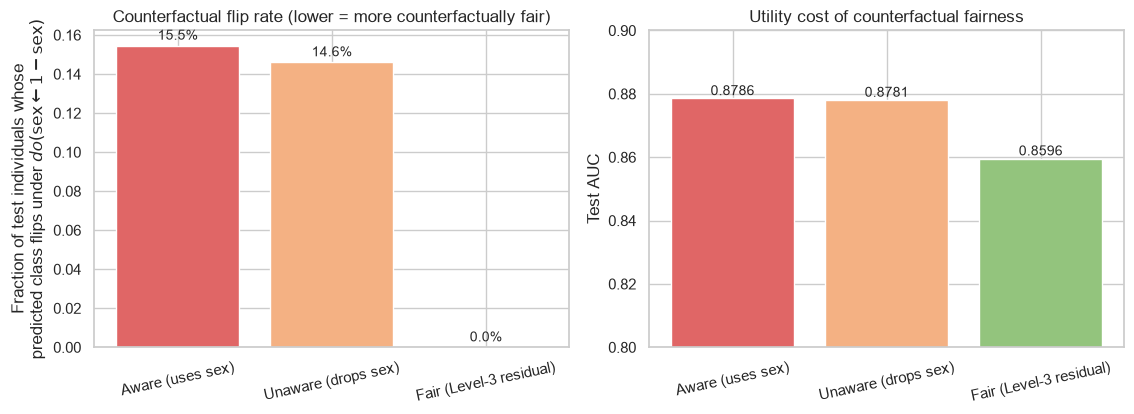

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

names = [results[k]["name"] for k in ["aware", "unaware", "fair"]]
flip_rates = [results[k]["flip_frac"] for k in ["aware", "unaware", "fair"]]
aucs = [results[k]["auc"] for k in ["aware", "unaware", "fair"]]
colors = ["#e06666", "#f4b183", "#93c47d"]

axes[0].bar(names, flip_rates, color=colors)
axes[0].set_ylabel("Fraction of test individuals whose\npredicted class flips under $do(\\text{sex} \\leftarrow 1-\\text{sex})$")
axes[0].set_title("Counterfactual flip rate (lower = more counterfactually fair)")
for i, v in enumerate(flip_rates):
    axes[0].text(i, v + 0.003, f"{v:.1%}", ha="center", fontsize=10)
axes[0].tick_params(axis="x", labelrotation=12)

axes[1].bar(names, aucs, color=colors)
axes[1].set_ylim(0.80, 0.90)
axes[1].set_ylabel("Test AUC")
axes[1].set_title("Utility cost of counterfactual fairness")
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=10)
axes[1].tick_params(axis="x", labelrotation=12)

plt.tight_layout()
plt.show()

### 3.3 A "naive" flip test — and why it understates the problem

A common shortcut practitioners take is to flip the protected attribute
*in the input row only*, leave every other feature exactly as observed, and
check whether the prediction changes. This is *not* the SCM-grounded
counterfactual recipe — it never propagates the flip through the causal
graph — so it can only ever detect a **direct** edge $A \to \hat Y$, missing
every indirect, mediator-borne pathway entirely. We run it on the Aware
model (the only one of our three with $A$ as an input) to show exactly how
much it understates the true counterfactual sensitivity we measured above.


In [10]:
Xte_aware = feat_aware[idx_te]
proba_naive = results["aware"]["clf"].predict_proba(Xte_aware)[:, 1]
pred_naive = (proba_naive >= 0.5).astype(int)

# naive flip: only the A column changes, mediators held at their FACTUAL raw values
Xte_naive_cf = Xte_aware.copy()
Xte_naive_cf[:, 0] = 1 - Xte_naive_cf[:, 0]
proba_naive_cf = results["aware"]["clf"].predict_proba(Xte_naive_cf)[:, 1]
pred_naive_cf = (proba_naive_cf >= 0.5).astype(int)

naive_flip_rate = float(np.mean(pred_naive_cf != pred_naive))
print(f"Naive flip-only-the-A-column test on the Aware model: {naive_flip_rate:.4f} "
      f"({int(naive_flip_rate*len(idx_te))}/{len(idx_te)})")
print(f"Full SCM-propagated counterfactual audit on the same model: {results['aware']['flip_frac']:.4f} "
      f"({int(results['aware']['flip_frac']*len(idx_te))}/{len(idx_te)})")
print(f"\nRatio: the naive test finds {naive_flip_rate / results['aware']['flip_frac']:.1%} "
      f"of the sensitivity the causal audit finds.")

Naive flip-only-the-A-column test on the Aware model: 0.0138 (125/9049)
Full SCM-propagated counterfactual audit on the same model: 0.1546 (1399/9049)

Ratio: the naive test finds 8.9% of the sensitivity the causal audit finds.


The naive test finds a small fraction of the sensitivity the causal
audit finds — because the logistic regression's *direct* coefficient on
`sex_bin` happens to be small once the mediators are already in the model
(the mediators "absorb" most of $A$'s explanatory power), so flipping only
the input column barely moves the score. But the real counterfactual world
— the one where this person's `married`, `hours_per_week`, and
`log_cap_gain` also would plausibly have been different — moves the score
far more, for a far larger share of people. **A naive, non-causal flip test
systematically understates counterfactual unfairness whenever the protected
attribute acts mostly through mediators rather than a direct edge into the
outcome** — precisely the pattern we found empirically in Section 3.1.


### 3.4 DiCE: individual counterfactual explanations, and a direct audit

[`dice-ml`](https://github.com/interpretml/DiCE) (Mothilal, Sharma & Tan,
2020) generates **counterfactual explanations**: given a denied individual,
find the smallest change to their *observed feature values* that flips the
model's decision. This is a different object from an SCM counterfactual —
DiCE searches over the raw, observed feature space directly and has no
notion of causal structure or mediators unless you constrain it to respect
one. We use it two ways: (1) the standard practitioner use case — actionable
recourse explanations — and (2) constrained to vary *only* `sex_bin`, as a
second, independent probe of the same direct-edge sensitivity the naive
test in 3.3 measured (and a demonstration that DiCE, used naively, has
exactly the same "does not see mediator effects" limitation as any
input-perturbation method).


In [11]:
import dice_ml
from dice_ml import Dice
from sklearn.base import BaseEstimator, ClassifierMixin

feat_cols = ["sex_bin", "age", "education_num", "married", "hours_per_week", "log_cap_gain"]
model_df = df[feat_cols + ["income_bin"]].copy()
for c in ["age", "education_num", "hours_per_week", "log_cap_gain"]:
    model_df[c] = model_df[c].astype(float)
# sex_bin/married are DiCE "categorical" (binary) features; object dtype avoids a
# pandas int64-block LossySetitemError when DiCE's random search assigns candidate values
model_df["sex_bin"] = model_df["sex_bin"].astype(object)
model_df["married"] = model_df["married"].astype(object)

train_df, test_df = train_test_split(model_df, test_size=0.3, random_state=0,
                                      stratify=model_df["income_bin"])
aware_clf = results["aware"]["clf"]  # already fit on [A, age, edu, married, hours, cap] in this column order

class SklearnWrapper(BaseEstimator, ClassifierMixin):
    # DiCE needs a model that accepts a DataFrame with mixed-looking dtypes; our
    # underlying LogisticRegression was fit on a plain float array in the same
    # column order, so this wrapper just enforces that at prediction time.
    def __init__(self, clf):
        self.clf = clf
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return self.clf.predict(np.asarray(X, dtype=float))
    def predict_proba(self, X):
        return self.clf.predict_proba(np.asarray(X, dtype=float))

wrapped_clf = SklearnWrapper(aware_clf)

d = dice_ml.Data(dataframe=train_df,
                  continuous_features=["age", "education_num", "hours_per_week", "log_cap_gain"],
                  outcome_name="income_bin")
m = dice_ml.Model(model=wrapped_clf, backend="sklearn")
dice_exp = Dice(d, m, method="random")

denied = test_df[test_df["income_bin"] == 0].sample(4, random_state=3)[feat_cols]
denied

,sex_bin,age,education_num,married,hours_per_week,log_cap_gain
3568,0,27.0,9.0,0,35.0,0.0
19198,0,20.0,10.0,0,20.0,0.0
1604,1,32.0,13.0,0,40.0,0.0
20791,1,36.0,12.0,0,50.0,0.0


In [12]:
# (1) Standard use: actionable counterfactual explanations, protected attribute excluded from what can vary
cf_explain = dice_exp.generate_counterfactuals(
    denied, total_CFs=2, desired_class="opposite",
    features_to_vary=["education_num", "married", "hours_per_week", "log_cap_gain"],
)

# Build the query + counterfactual rows into one comparison table (avoids a dtype
# quirk in DiCE's built-in visualize_as_dataframe when categorical cols are object dtype)
rows = []
for i, cf_ex in enumerate(cf_explain.cf_examples_list):
    query_row = cf_ex.test_instance_df.copy()
    query_row.insert(0, "who", f"person {i+1} (observed)")
    rows.append(query_row)
    cfs = cf_ex.final_cfs_df.copy()
    cfs.insert(0, "who", [f"person {i+1} -> counterfactual {j+1}" for j in range(len(cfs))])
    rows.append(cfs)
cf_table = pd.concat(rows, ignore_index=True)
cf_table

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:00<00:00,  4.66it/s]

 50%|█████     | 2/4 [00:00<00:00,  4.62it/s]

 75%|███████▌  | 3/4 [00:00<00:00,  3.10it/s]

100%|██████████| 4/4 [00:01<00:00,  3.61it/s]

100%|██████████| 4/4 [00:01<00:00,  3.67it/s]

,who,sex_bin,age,education_num,married,hours_per_week,log_cap_gain,income_bin
0,person 1 (observed),0,27.0,9.0,0,35.0,0.0,0
1,person 1 -> counterfactual 1,0,27.0,16.1,1,35.0,0.0,1
2,person 1 -> counterfactual 2,0,27.0,14.0,0,35.0,11.3,1
3,person 2 (observed),0,20.0,10.0,0,20.0,0.0,0
4,person 2 -> counterfactual 1,0,20.0,10.0,1,20.0,11.0,1
5,person 2 -> counterfactual 2,0,20.0,10.0,1,20.0,11.4,1
6,person 3 (observed),1,32.0,13.0,0,40.0,0.0,0
7,person 3 -> counterfactual 1,1,32.0,14.9,1,40.0,0.0,1
8,person 3 -> counterfactual 2,1,32.0,13.0,0,44.2,11.2,1
9,person 4 (observed),1,36.0,12.0,0,50.0,0.0,0


These are legitimate, actionable recourse suggestions — "work more
hours" or "the model would flip you to the high-income class if
`log_cap_gain` were higher" — computed without ever touching the protected
attribute, exactly as DiCE is normally used for explainability. It answers
"what would need to change about this observed row," which is a genuinely
different question from "what would have been different about this row had
this person's sex been different" (Section 3.2's SCM audit).


In [13]:
# (2) Direct audit: constrain DiCE to vary sex_bin ONLY (no mediator propagation),
#     matching the naive test in 3.3 -- try it across a larger sample of denied individuals
import contextlib, io as _io

denied_batch = test_df[test_df["income_bin"] == 0].sample(30, random_state=11)[feat_cols]

n_found = 0
_silence = _io.StringIO()
for i in range(len(denied_batch)):
    row = denied_batch.iloc[[i]]
    try:
        with contextlib.redirect_stdout(_silence), contextlib.redirect_stderr(_silence):
            cf_sex = dice_exp.generate_counterfactuals(
                row, total_CFs=1, desired_class="opposite", features_to_vary=["sex_bin"], verbose=False,
            )
        found = cf_sex.cf_examples_list[0].final_cfs_df is not None
    except Exception:
        found = False
    n_found += int(found)

print(f"DiCE found a sex-only counterfactual that flips the prediction for "
      f"{n_found}/{len(denied_batch)} denied individuals ({n_found/len(denied_batch):.1%}).")
print("Consistent with Section 3.3: the direct sex->income edge in the Aware model is weak, "
      "so a sex-only perturbation rarely has enough leverage on its own to flip the decision -- "
      "even though the full causal audit found the model's predictions ARE sensitive to sex "
      "once its effect on married/hours/capital-gain is allowed to propagate.")

DiCE found a sex-only counterfactual that flips the prediction for 0/30 denied individuals (0.0%).
Consistent with Section 3.3: the direct sex->income edge in the Aware model is weak, so a sex-only perturbation rarely has enough leverage on its own to flip the decision -- even though the full causal audit found the model's predictions ARE sensitive to sex once its effect on married/hours/capital-gain is allowed to propagate.


## 4. Use cases

- **Credit and lending underwriting.** Regulators (US ECOA/Reg B,
  EU consumer credit directives) already require lenders to reason about
  whether a factor is a legitimate credit risk driver or a proxy for a
  protected class; counterfactual fairness formalizes "proxy" as
  "descendant of $A$ in the causal graph" and gives a testable audit rather
  than a judgment call per feature.
- **Criminal justice risk assessment.** The COMPAS-style debate covered in
  `fairness-group-vs-individual` is usually fought on group metrics; a
  counterfactual audit asks the sharper question directly relevant to due
  process — would *this specific defendant's* score have been different had
  their race been different, holding who they actually are fixed?
- **Hiring and admissions.** Kusner et al.'s own paper uses law-school
  admissions and GPA/LSAT prediction as the motivating example: whether
  standardized test scores are legitimate non-descendants of race/sex or
  whether they're themselves shaped by unequal access to test preparation
  (a descendant pathway) is precisely the kind of graph-construction
  argument this framework forces into the open.
- **Healthcare risk scores.** Clinical risk models that use zip code, prior
  utilization, or insurance type as features can encode historical
  disparate access to care as a descendant pathway of race — counterfactual
  audits are increasingly proposed (though rarely deployed end-to-end) in
  clinical fairness reviews for exactly this reason.
- **Algorithmic recourse tooling.** DiCE-style counterfactual explanation
  is now common in production explainability stacks (credit denial reason
  codes, hiring-platform "why was I rejected" tooling); Section 3.4 is a
  realistic sketch of how such a tool is actually invoked, and where its
  blind spot (no causal structure) lies.


## 5. Limitations & debates

**The causal graph is not identifiable from observational data.** Pearl's
causal hierarchy theorem says, roughly: association (level 1) is estimable
from observational data; interventions and counterfactuals (levels 2-3)
generally are not, without either experimental data or untestable
structural assumptions (Pearl, *Causality*, 2009; Bareinboim, Correa, Ibeling
& Icard, *On Pearl's Hierarchy and the Foundations of Causal Inference*,
2022). Section 3.1 fit *one* graph and found `education_num` empirically
uncorrelated with `sex_bin` given `age` — but a different, equally
defensible analyst could argue education access *was* historically gendered
in ways this cross-sectional 1994 snapshot cannot detect (e.g. field-of-study
segregation collapsed into a single `education_num` scalar, or a cohort
effect confounded with an age control that's too coarse), and add the edge
back in. **Two analysts, each reasonable, each honest, can build different
SCMs from the same data and reach opposite counterfactual-fairness verdicts
for the same model** — and nothing in the observational data can adjudicate
between them, because the disagreement is about counterfactual claims,
which live at level 3 of the hierarchy where observational data is silent.
This is not a hypothetical: it is the single most common criticism of the
entire counterfactual fairness research program (Kusner et al. themselves
flag it; see also Kilbertus et al., *Avoiding Discrimination through Causal
Reasoning*, NeurIPS 2017, on the same identifiability gap from an
independent angle).

**Full path-blocking can destroy predictive utility.** Section 3.2's
concrete numbers show this directly: the Level-3 "Fair" residual model's
AUC is measurably lower than the Aware/Unaware models'. This is not a
tuning artifact — it is the mathematically expected consequence of removing
every component of a feature that correlates with $A$, even when that
component also correlates with the *legitimate* predictive signal. When a
protected attribute is causally entangled with genuinely predictive
information (e.g. hours worked is a real productivity signal *and* is
partly caused by sex-linked social structures in this data), a
counterfactually fair predictor is forced to throw away the entangled part
even where it would have been legitimate to use. There is no general,
assumption-free way to separate "the part of hours-worked that's a fair
signal" from "the part that's fallout from unequal caregiving norms" using
observational data alone — the SCM's structural equations *assume* an
answer (here, a specific linear decomposition), they don't derive one.

**The philosophical coherence of intervening on a social category is
contested.** $do(\text{sex} = a')$ or $do(\text{race} = a')$ presumes we can
meaningfully hold "the same person" fixed while changing an attribute that,
for many scholars, is not exogenous to who a person *is* — it's entangled
with their entire lived history, socialization, and how they were treated
by every institution they ever passed through. Kasirzadeh & Smart (*The Use
and Misuse of Counterfactuals in Ethical Machine Learning*, FAccT 2021)
argue that treating race or sex as a variable amenable to `do`-style
manipulation imports a substantive and often unexamined metaphysical
commitment: it treats a social category as if it functioned like a
manipulable physical variable (dosage, temperature), when race in
particular is frequently theorized as constituted by, not merely
correlated with, social treatment — making "what would this person's
income have been had they been a different race, everything else about
them held fixed" arguably ill-posed rather than merely hard to estimate.
Kohler-Hausmann (*Eddie Murphy and the Dangers of Counterfactual Causal
Thinking About Detecting Racial Discrimination*, Northwestern University
Law Review, 2019) makes a related legal-theory argument: race-swap
thought experiments (literally, "Eddie Murphy in whiteface") smuggle in
assumptions about which of a person's other traits would "naturally" go
along with the swap, and different smuggled assumptions produce different
verdicts about the same case. None of this makes the SCM machinery in
Sections 1-3 useless — it is a genuinely sharper question than group
fairness for many *legitimately manipulable* mediators (hours worked,
credit history) — but applying it to $A$ itself, rather than to a
downstream policy lever, is where the framework's critics say it overreaches.

**Practical takeaway.** Treat counterfactual fairness as what it is: a
precise language for reasoning about mediator pathways once you've
committed to a graph, not a way to avoid committing to one. Report the
graph and its assumptions alongside any counterfactual-fairness number, the
same way you'd report a regression's specification — because, as Section
3.1 showed, the number changes if the graph does.


## 6. References

- Kusner, Loftus, Russell, Silva. *Counterfactual Fairness*. NeurIPS 2017.
- Pearl. *Causality: Models, Reasoning, and Inference*, 2nd ed. Cambridge
  University Press, 2009.
- Pearl, Glymour, Jewell. *Causal Inference in Statistics: A Primer*. Wiley,
  2016.
- Bareinboim, Correa, Ibeling, Icard. *On Pearl's Hierarchy and the
  Foundations of Causal Inference*. In *Probabilistic and Causal Inference:
  The Works of Judea Pearl*, ACM Books, 2022.
- Kilbertus, Rojas-Carulla, Parascandolo, Hardt, Janzing, Schölkopf.
  *Avoiding Discrimination through Causal Reasoning*. NeurIPS 2017.
- Kasirzadeh, Smart. *The Use and Misuse of Counterfactuals in Ethical
  Machine Learning*. FAccT 2021.
- Kohler-Hausmann. *Eddie Murphy and the Dangers of Counterfactual Causal
  Thinking About Detecting Racial Discrimination*. Northwestern University
  Law Review, 2019.
- Mothilal, Sharma, Tan. *Explaining Machine Learning Classifiers through
  Diverse Counterfactual Explanations*. FAT* 2020 (`dice-ml`).
- Kohavi. *Scaling Up the Accuracy of Naive-Bayes Classifiers: a
  Decision-Tree Hybrid*. KDD 1996 (introduces the UCI Adult dataset).
- This repo's [`fairness-group-vs-individual`](../fairness-group-vs-individual/tutorial.ipynb)
  tutorial — demographic parity, equalized odds, predictive parity, and
  Dwork et al.'s individual fairness, referenced throughout Section 1.4.
